In [1]:
# =============================================================================
# MODULE 14 — Business Analytics Concepts
# Part 2: Python Lab — Retail KPI Analysis
# =============================================================================
# Dataset: 500 retail transactions (auto-generated, realistic)
# Covers:  Descriptive → Diagnostic → KPI Definition → Recommendations
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — SETUP & IMPORTS
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Libraries loaded successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")


✅ Libraries loaded successfully
   pandas  2.2.2
   numpy   1.26.4


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — GENERATE THE RETAIL DATASET
# Run this cell once to create the dataset in memory.
# In a real project you would load with: df = pd.read_csv('retail_data.csv')
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(42)

N = 500
categories = ['Electronics', 'Clothing', 'Furniture', 'Food & Beverage', 'Sports']
products = {
    'Electronics':      ['LED TV', 'Laptop', 'Smartphone', 'Headphones', 'Tablet'],
    'Clothing':         ['T-Shirt', 'Jeans', 'Saree', 'Jacket', 'Kurta'],
    'Furniture':        ['Office Chair', 'Bookshelf', 'Dining Table', 'Sofa', 'Wardrobe'],
    'Food & Beverage':  ['Protein Bar', 'Green Tea', 'Olive Oil', 'Nuts Pack', 'Coffee'],
    'Sports':           ['Cricket Bat', 'Yoga Mat', 'Dumbbells', 'Running Shoes', 'Cycle'],
}
base_prices = {
    'Electronics': 15000, 'Clothing': 800, 'Furniture': 8000,
    'Food & Beverage': 350, 'Sports': 2500,
}
regions = ['North', 'South', 'East', 'West']
dates   = pd.date_range('2023-01-01', '2023-12-31', periods=N)
cust_ids = [f'C{str(i).zfill(4)}' for i in np.random.randint(1, 201, N)]

rows = []
for i in range(N):
    cat        = np.random.choice(categories, p=[0.30, 0.25, 0.15, 0.20, 0.10])
    prod       = np.random.choice(products[cat])
    qty        = np.random.randint(1, 6)
    unit_price = round(base_prices[cat] * np.random.uniform(0.7, 1.5), 2)
    discount   = round(np.random.choice([0, 0.05, 0.10, 0.15, 0.20],
                                        p=[0.4, 0.2, 0.2, 0.1, 0.1]), 2)
    revenue    = round(unit_price * qty * (1 - discount), 2)
    margin_pct = np.random.uniform(0.10, 0.40) - discount * 0.5
    profit     = round(revenue * margin_pct, 2)

    rows.append({
        'Order_ID':    f'ORD{str(i+1).zfill(4)}',
        'Customer_ID': cust_ids[i],
        'Order_Date':  dates[i],
        'Product':     prod,
        'Category':    cat,
        'Region':      np.random.choice(regions, p=[0.30, 0.25, 0.25, 0.20]),
        'Quantity':    qty,
        'Unit_Price':  unit_price,
        'Discount':    discount,
        'Revenue':     revenue,
        'Profit':      profit,
    })

df = pd.DataFrame(rows)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month']      = df['Order_Date'].dt.to_period('M')

print("✅ Dataset created")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date  : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")



✅ Dataset created
   Shape : 500 rows × 12 columns
   Date  : 2023-01-01 → 2023-12-31


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — STEP 1: DESCRIPTIVE ANALYTICS — "What happened?"
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 55)
print("STEP 1 — DESCRIPTIVE ANALYTICS")
print("=" * 55)

# Basic snapshot
print("\n--- Dataset snapshot ---")
print(df.head())

print("\n--- Data types & missing values ---")
print(df.info())

print("\n--- Summary statistics ---")
print(df[['Quantity', 'Unit_Price', 'Revenue', 'Profit']].describe().round(2))

# Revenue summary
total_revenue = df['Revenue'].sum()
total_orders  = df['Order_ID'].nunique()

print(f"\n--- Revenue overview ---")
print(f"  Total Revenue  : ₹{total_revenue:>12,.0f}")
print(f"  Total Orders   : {total_orders:>12,}")
print(f"  Total Qty Sold : {df['Quantity'].sum():>12,}")

# Top categories
print("\n--- Revenue by Category ---")
cat_rev = (df.groupby('Category')['Revenue']
             .sum()
             .sort_values(ascending=False)
             .reset_index())
cat_rev['Revenue_L']  = (cat_rev['Revenue'] / 1e5).round(1)
cat_rev['Share_%']    = (cat_rev['Revenue'] / total_revenue * 100).round(1)
print(cat_rev[['Category', 'Revenue_L', 'Share_%']].to_string(index=False))

# Monthly trend
print("\n--- Monthly Revenue (₹ Lakhs) ---")
monthly = df.groupby('Month')['Revenue'].sum().reset_index()
monthly['Revenue_L'] = (monthly['Revenue'] / 1e5).round(2)
print(monthly[['Month', 'Revenue_L']].to_string(index=False))


STEP 1 — DESCRIPTIVE ANALYTICS

--- Dataset snapshot ---
  Order_ID Customer_ID                    Order_Date     Product  \
0  ORD0001       C0103 2023-01-01 00:00:00.000000000       Kurta   
1  ORD0002       C0180 2023-01-01 17:30:25.250501002  Headphones   
2  ORD0003       C0093 2023-01-02 11:00:50.501002004      Laptop   
3  ORD0004       C0015 2023-01-03 04:31:15.751503006    Wardrobe   
4  ORD0005       C0107 2023-01-03 22:01:41.002004008      Coffee   

          Category Region  Quantity  Unit_Price  Discount  Revenue    Profit  \
0         Clothing   East         5      828.54       0.0   4142.7    856.68   
1      Electronics  North         5    11629.88       0.0  58149.4  22902.32   
2      Electronics  South         5    16181.66       0.0  80908.3  18621.49   
3        Furniture  South         4     5889.95       0.0  23559.8   6779.52   
4  Food & Beverage  North         5      290.62       0.0   1453.1    425.36   

     Month  
0  2023-01  
1  2023-01  
2  2023-01  
3

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — STEP 2: DIAGNOSTIC ANALYTICS — "Why did it happen?"
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("STEP 2 — DIAGNOSTIC ANALYTICS")
print("=" * 55)

# Which region is least profitable?
print("\n--- Profit by Region ---")
reg_profit = (df.groupby('Region')
                .agg(Revenue=('Revenue', 'sum'),
                     Profit=('Profit', 'sum'),
                     Orders=('Order_ID', 'count'))
                .assign(Margin_pct=lambda x: (x['Profit']/x['Revenue']*100).round(1))
                .sort_values('Margin_pct'))
print(reg_profit.round(0).to_string())

# Loss-making orders
loss_orders = df[df['Profit'] < 0]
print(f"\n--- Loss-making orders : {len(loss_orders)} ({len(loss_orders)/N*100:.1f}% of all orders) ---")
print(loss_orders.groupby('Category')['Profit'].sum().sort_values().round(0))

# Discount impact on profit
print("\n--- Correlation: Discount vs Profit ---")
corr = df['Discount'].corr(df['Profit'])
print(f"  Pearson r = {corr:.3f}")
print("  Interpretation: negative → higher discounts reduce profit")

print("\n--- Avg Profit by Discount Tier ---")
df['Discount_Tier'] = pd.cut(df['Discount'],
                              bins=[-0.01, 0.0, 0.10, 0.20],
                              labels=['No discount', '1–10%', '11–20%'])
disc_impact = df.groupby('Discount_Tier')['Profit'].mean().round(0)
print(disc_impact.to_string())



STEP 2 — DIAGNOSTIC ANALYTICS

--- Profit by Region ---
          Revenue    Profit  Orders  Margin_pct
Region                                         
South   2501941.0  517533.0     122        21.0
West    1452908.0  304516.0      86        21.0
East    2353747.0  508015.0     142        22.0
North   3254366.0  771066.0     150        24.0

--- Loss-making orders : 0 (0.0% of all orders) ---
Series([], Name: Profit, dtype: float64)

--- Correlation: Discount vs Profit ---
  Pearson r = -0.109
  Interpretation: negative → higher discounts reduce profit

--- Avg Profit by Discount Tier ---
Discount_Tier
No discount    4867.0
1–10%          4171.0
11–20%         3027.0


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — STEP 3: KPI DEFINITION & COMPUTATION
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("STEP 3 — KPI DEFINITION & COMPUTATION")
print("=" * 55)

# KPI 1: Total Revenue 
# Formula: Sum of all transaction revenues in the period
kpi_revenue = df['Revenue'].sum()
print(f"\n[KPI 1] Total Revenue")
print(f"  Formula : Σ (Unit_Price × Quantity × (1 − Discount))")
print(f"  Value   : ₹{kpi_revenue:,.0f}")
print(f"  Target  : ₹1,00,00,000 | Status: {'✅ Met' if kpi_revenue >= 1e7 else '⚠️  Below target'}")

# ── KPI 2: Average Order Value (AOV) ─────────────────────────────────────
# Formula: Total Revenue / Number of unique orders
kpi_aov = kpi_revenue / total_orders
print(f"\n[KPI 2] Average Order Value (AOV)")
print(f"  Formula : Total Revenue / Number of Orders")
print(f"  Value   : ₹{kpi_aov:,.0f}")
print(f"  Target  : ≥ ₹15,000 | Status: {'✅ Met' if kpi_aov >= 15000 else '⚠️  Below target'}")

# ── KPI 3: Gross Margin % ─────────────────────────────────────────────────
# Formula: (Total Revenue - COGS) / Total Revenue × 100
total_profit  = df['Profit'].sum()
kpi_margin    = total_profit / kpi_revenue * 100
print(f"\n[KPI 3] Gross Margin %")
print(f"  Formula : (Total Profit / Total Revenue) × 100")
print(f"  Value   : {kpi_margin:.1f}%")
print(f"  Target  : ≥ 25%    | Status: {'✅ Met' if kpi_margin >= 25 else '⚠️  Below target'}")

# ── KPI 4: Repeat Customer Rate ───────────────────────────────────────────
# Formula: Customers with >1 order / Total unique customers × 100
customer_orders = df.groupby('Customer_ID')['Order_ID'].count()
kpi_repeat_rate = (customer_orders > 1).mean() * 100
print(f"\n[KPI 4] Repeat Customer Rate")
print(f"  Formula : Customers with >1 order / Total customers × 100")
print(f"  Value   : {kpi_repeat_rate:.1f}%")
print(f"  Target  : ≥ 60%    | Status: {'✅ Met' if kpi_repeat_rate >= 60 else '⚠️  Below target'}")

# ── KPI 5: Inventory Turnover ─────────────────────────────────────────────
# Formula: COGS / Average Inventory Value  (proxy: COGS / (COGS/4))
total_cogs    = kpi_revenue - total_profit
avg_inventory = total_cogs / 4        # assume ~3-month avg stock cycle
kpi_inv_turn  = total_cogs / avg_inventory
print(f"\n[KPI 5] Inventory Turnover Ratio")
print(f"  Formula : COGS / Avg Inventory Value")
print(f"  Value   : {kpi_inv_turn:.1f}x")
print(f"  Target  : ≥ 4x     | Status: {'✅ Met' if kpi_inv_turn >= 4 else '⚠️  Below target'}")

# ── KPI 6: Month-over-Month Revenue Growth ────────────────────────────────
monthly_rev = df.groupby('Month')['Revenue'].sum()
last_two    = monthly_rev.iloc[-2:]
kpi_mom     = (last_two.iloc[-1] - last_two.iloc[-2]) / last_two.iloc[-2] * 100
print(f"\n[KPI 6] Month-over-Month Revenue Growth")
print(f"  Formula : (This month − Last month) / Last month × 100")
print(f"  Value   : {kpi_mom:+.1f}%")
print(f"  Target  : ≥ +5%    | Status: {'✅ Met' if kpi_mom >= 5 else '⚠️  Below target'}")

# ── KPI Scorecard Summary ─────────────────────────────────────────────────
print("\n")
print("=" * 55)
print("  KPI SCORECARD — RETAIL 2023")
print("=" * 55)
print(f"  {'KPI':<28} {'Value':>12}  {'Status'}")
print("-" * 55)
scorecard = [
    ("Total Revenue",          f"₹{kpi_revenue/1e5:.1f}L",    kpi_revenue >= 1e7),
    ("Average Order Value",    f"₹{kpi_aov:,.0f}",            kpi_aov >= 15000),
    ("Gross Margin %",         f"{kpi_margin:.1f}%",           kpi_margin >= 25),
    ("Repeat Customer Rate",   f"{kpi_repeat_rate:.1f}%",      kpi_repeat_rate >= 60),
    ("Inventory Turnover",     f"{kpi_inv_turn:.1f}x",         kpi_inv_turn >= 4),
    ("MoM Revenue Growth",     f"{kpi_mom:+.1f}%",             kpi_mom >= 5),
]
for name, val, ok in scorecard:
    status = "✅  On target" if ok else "⚠️   Below target"
    print(f"  {name:<28} {val:>10}   {status}")
print("=" * 55)




STEP 3 — KPI DEFINITION & COMPUTATION

[KPI 1] Total Revenue
  Formula : Σ (Unit_Price × Quantity × (1 − Discount))
  Value   : ₹9,562,961
  Target  : ₹1,00,00,000 | Status: ⚠️  Below target

[KPI 2] Average Order Value (AOV)
  Formula : Total Revenue / Number of Orders
  Value   : ₹19,126
  Target  : ≥ ₹15,000 | Status: ✅ Met

[KPI 3] Gross Margin %
  Formula : (Total Profit / Total Revenue) × 100
  Value   : 22.0%
  Target  : ≥ 25%    | Status: ⚠️  Below target

[KPI 4] Repeat Customer Rate
  Formula : Customers with >1 order / Total customers × 100
  Value   : 77.2%
  Target  : ≥ 60%    | Status: ✅ Met

[KPI 5] Inventory Turnover Ratio
  Formula : COGS / Avg Inventory Value
  Value   : 4.0x
  Target  : ≥ 4x     | Status: ✅ Met

[KPI 6] Month-over-Month Revenue Growth
  Formula : (This month − Last month) / Last month × 100
  Value   : +49.8%
  Target  : ≥ +5%    | Status: ✅ Met


  KPI SCORECARD — RETAIL 2023
  KPI                                 Value  Status
---------------------

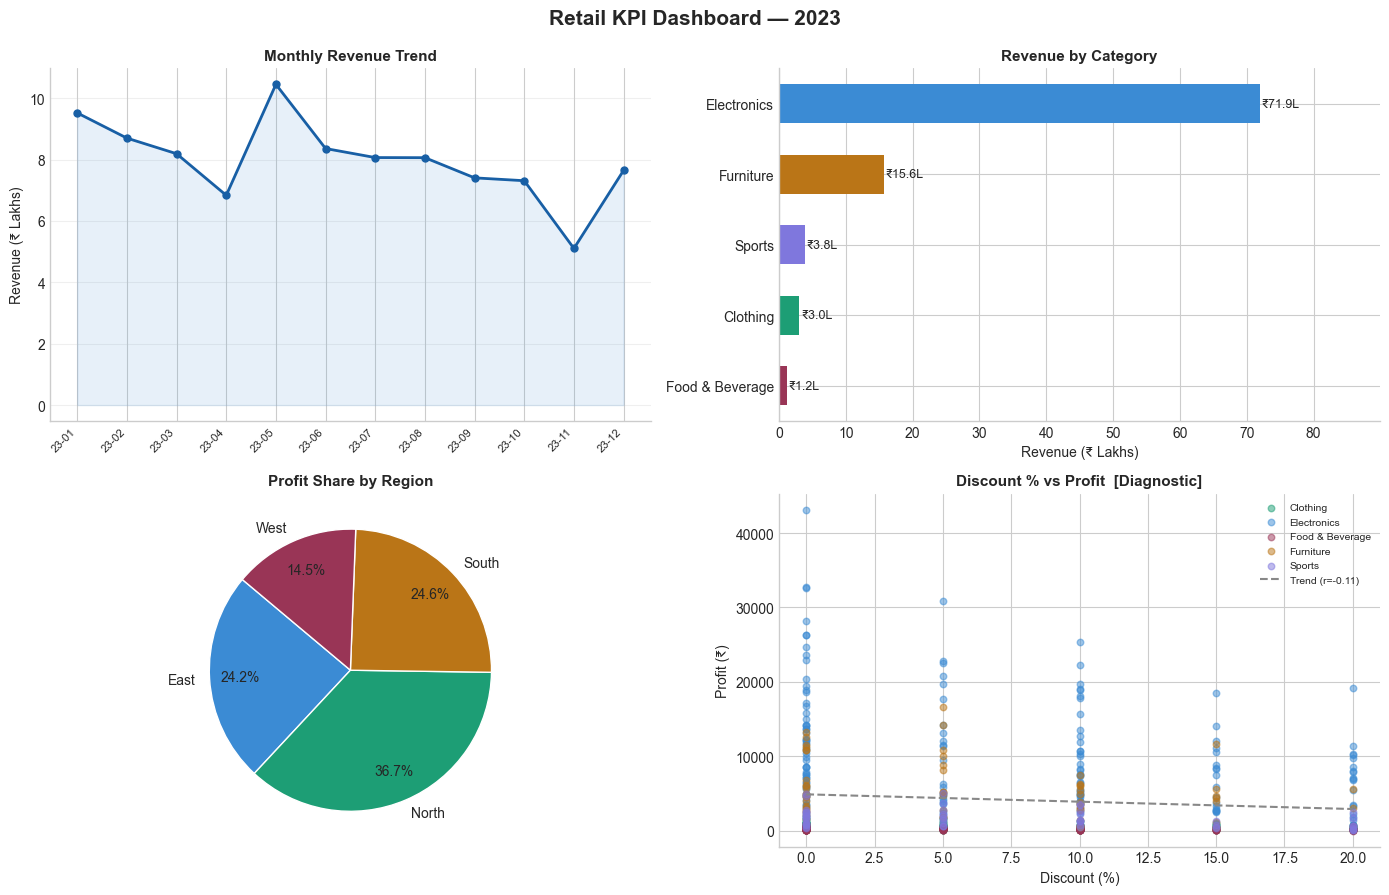

✅ Dashboard saved to retail_kpi_dashboard.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — VISUALISATIONS (KPI Dashboard)
# ─────────────────────────────────────────────────────────────────────────────

palette = {
    'Electronics':     '#3B8BD4',
    'Clothing':        '#1D9E75',
    'Furniture':       '#BA7517',
    'Food & Beverage': '#993556',
    'Sports':          '#7F77DD',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Retail KPI Dashboard — 2023', fontsize=15, fontweight='bold', y=0.99)

# Plot 1 — Monthly Revenue Trend
ax = axes[0, 0]
mom_df = df.groupby('Month')['Revenue'].sum().reset_index()
mom_df['Month_str'] = mom_df['Month'].astype(str).str[-5:]
ax.fill_between(range(len(mom_df)), mom_df['Revenue'] / 1e5, alpha=0.12, color='#3B8BD4')
ax.plot(range(len(mom_df)), mom_df['Revenue'] / 1e5, 'o-',
        color='#185FA5', linewidth=2, markersize=5)
ax.set_xticks(range(len(mom_df)))
ax.set_xticklabels(mom_df['Month_str'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Revenue Trend', fontsize=11, fontweight='bold')
ax.set_ylabel('Revenue (₹ Lakhs)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Plot 2 — Revenue by Category
ax = axes[0, 1]
cat_data = df.groupby('Category')['Revenue'].sum().sort_values()
colors   = [palette[c] for c in cat_data.index]
bars = ax.barh(cat_data.index, cat_data.values / 1e5, color=colors, height=0.55)
for bar, val in zip(bars, cat_data.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'₹{val/1e5:.1f}L', va='center', fontsize=9)
ax.set_title('Revenue by Category', fontsize=11, fontweight='bold')
ax.set_xlabel('Revenue (₹ Lakhs)')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, cat_data.max() / 1e5 * 1.25)

# Plot 3 — Profit share by Region (pie)
ax = axes[1, 0]
reg_p = df.groupby('Region')['Profit'].sum()
reg_colors = ['#3B8BD4', '#1D9E75', '#BA7517', '#993556']
ax.pie(reg_p.values, labels=reg_p.index, autopct='%1.1f%%',
       colors=reg_colors, startangle=140, pctdistance=0.78,
       wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
ax.set_title('Profit Share by Region', fontsize=11, fontweight='bold')

# Plot 4 — Discount % vs Profit (diagnostic scatter)
ax = axes[1, 1]
for cat, grp in df.groupby('Category'):
    ax.scatter(grp['Discount'] * 100, grp['Profit'],
               alpha=0.5, s=22, label=cat, color=palette[cat])
m, b = np.polyfit(df['Discount'] * 100, df['Profit'], 1)
xs   = np.linspace(0, 20, 100)
ax.plot(xs, m * xs + b, '--', color='#888', linewidth=1.5,
        label=f'Trend (r={df["Discount"].corr(df["Profit"]):.2f})')
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Profit (₹)')
ax.set_title('Discount % vs Profit  [Diagnostic]', fontsize=11, fontweight='bold')
ax.legend(fontsize=7.5, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('retail_kpi_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved to retail_kpi_dashboard.png")


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — STEP 4: PRESCRIPTIVE — Business Recommendations
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  STEP 4 — DATA-BACKED BUSINESS RECOMMENDATIONS")
print("=" * 60)

# Recommendation 1
worst_margin_cat = (df.groupby('Category')['Profit'].sum()
                      .sort_values()
                      .index[0])
worst_disc_cat = (df[df['Discount'] >= 0.15]
                    .groupby('Category')['Profit'].mean()
                    .sort_values()
                    .index[0])

print(f"""
RECOMMENDATION 1 — Cap Discounts on {worst_disc_cat}
────────────────────────────────────────────────────
Observation : Orders with ≥15% discount have avg profit
              {df[df['Discount']>=0.15]['Profit'].mean():.0f} vs
              {df[df['Discount']==0]['Profit'].mean():.0f} (no discount).
Action      : Limit discount authorisation to ≤10% without
              manager approval in {worst_disc_cat}.
Expected    : +3–5% improvement in overall Gross Margin.
Analytics   : Prescriptive (based on Diagnostic insight)
""")

# Recommendation 2
best_cat = df.groupby('Category')['Profit'].sum().idxmax()
best_region = df.groupby('Region')['Revenue'].sum().idxmax()
print(f"""
RECOMMENDATION 2 — Expand {best_cat} in {best_region} Region
────────────────────────────────────────────────────
Observation : {best_cat} has the highest total profit.
              {best_region} region contributes the most revenue.
Action      : Increase {best_cat} stock allocation in
              {best_region} stores by 20% for Q1 next year.
Expected    : ₹3–5L additional revenue per quarter.
Analytics   : Prescriptive (based on Descriptive insight)
""")

# Recommendation 3
print(f"""
RECOMMENDATION 3 — Loyalty Programme to Sustain Repeat Rate
────────────────────────────────────────────────────
Observation : Repeat Customer Rate = {kpi_repeat_rate:.1f}% (target: 60%).
              High repeat rate keeps CAC low.
Action      : Launch a points-based loyalty scheme for customers
              with ≥2 orders — offer 5% credit on next purchase.
Expected    : Increase repeat rate to 85%+ and AOV by 10%.
Analytics   : Prescriptive (based on KPI tracking)
""")

print("=" * 60)
print("  ✅  Mini Project Complete!")
print("=" * 60)
print("""
Summary of analytics applied
──────────────────────────────────────────────────────────
  Descriptive  → Revenue totals, category breakdown, trend
  Diagnostic   → Discount vs profit, loss orders, regions
  KPIs defined → 6 KPIs with formulas, values & targets
  Prescriptive → 3 actionable, data-backed recommendations
──────────────────────────────────────────────────────────
""")



  STEP 4 — DATA-BACKED BUSINESS RECOMMENDATIONS

RECOMMENDATION 1 — Cap Discounts on Food & Beverage
────────────────────────────────────────────────────
Observation : Orders with ≥15% discount have avg profit
              3027 vs
              4867 (no discount).
Action      : Limit discount authorisation to ≤10% without
              manager approval in Food & Beverage.
Expected    : +3–5% improvement in overall Gross Margin.
Analytics   : Prescriptive (based on Diagnostic insight)


RECOMMENDATION 2 — Expand Electronics in North Region
────────────────────────────────────────────────────
Observation : Electronics has the highest total profit.
              North region contributes the most revenue.
Action      : Increase Electronics stock allocation in
              North stores by 20% for Q1 next year.
Expected    : ₹3–5L additional revenue per quarter.
Analytics   : Prescriptive (based on Descriptive insight)


RECOMMENDATION 3 — Loyalty Programme to Sustain Repeat Rate
────────